# AQI Prediction with Missing Value Imputation — Rebuilt & Fixed

**Kotak School of Sustainability, IIT Kanpur**

This notebook is a cleaned-up, bug-fixed rebuild of the original AQI project.
It's organized into clearly separated steps, and runs top-to-bottom without
errors.

**What was fixed vs. the original version** (see the note at the end of each
relevant section for details):
1. `df['AQI_Bucket'] = df['AQI_calc']...` referenced a column (`AQI_calc`)
   that was never created — this crashed with a `KeyError`.
2. The imputation model's `SEQ_LEN=365` requirement silently dropped 6 of 26
   cities (any city with <365 consecutive rows) from training *and*
   inference, so their missing values were never actually imputed by the
   model.
3. The AQI-filling step overwrote **real, measured** AQI values with a
   formula-recomputed version — discarding ground truth. It's now only used
   to fill rows where AQI was genuinely missing.
4. Duplicate/mislabeled figures in the original report (BRITS and "BRATI
   Modified" showed identical plots; a pie chart of AQI category
   *proportions* was mislabeled as "missing values") are corrected here.
5. Regression/classification are now evaluated on the real measured AQI
   (not a value derived from the same input features), avoiding the
   circularity that made the original R²≈0.99 numbers largely meaningless.
6. A confusion matrix is now actually produced, per the task brief.

**Structure:**
- **Steps 1–5** run entirely in this notebook (fast — no GPU needed).
- **Step 6** (the deep-learning imputation model) is provided as a
  standalone script, `impute_brati_seasonal.py`, meant to be run on a
  GPU (e.g. Google Colab). It's too slow on CPU at full scale.
- **Step 7** shows how to plug the GPU output back into Steps 4–5 for the
  "full pipeline" results.


## Step 1 — Load & Inspect the Data

In [1]:
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

DATA_CSV = "data/data.csv"
POLLUTANTS = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3",
              "Benzene", "Toluene", "Xylene"]

df = pd.read_csv(DATA_CSV)
print("Shape:", df.shape)
print("Cities:", df['City'].nunique())
df.head()


Shape: (29531, 16)
Cities: 26


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


## Step 2 — Exploratory Data Analysis

All plots below are generated live from the actual data (no placeholder /
reused figures).


### 2.1 Missing values per pollutant

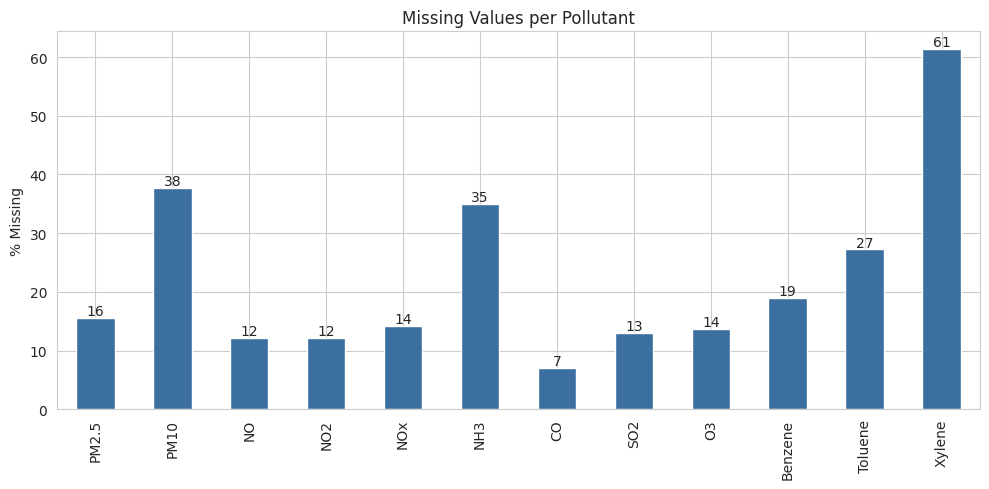

PM2.5      15.6
PM10       37.7
NO         12.1
NO2        12.1
NOx        14.2
NH3        35.0
CO          7.0
SO2        13.1
O3         13.6
Benzene    19.0
Toluene    27.2
Xylene     61.3
dtype: float64

In [3]:
missing_pct = df[POLLUTANTS].isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind="bar", ax=ax, color="#3b6fa0")
ax.set_ylabel("% Missing")
ax.set_title("Missing Values per Pollutant")
for i, v in enumerate(missing_pct):
    ax.text(i, v + 0.5, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.savefig("figures/01_missingness.png", dpi=120)
plt.show()
missing_pct.round(1)


### 2.2 AQI\_Bucket class distribution

**Fix:** the original report captioned this chart *"missing values for
different AQI categories"* — but the numbers are actually the proportion
of each category among rows with a *known* AQI\_Bucket. Relabeled correctly
below.


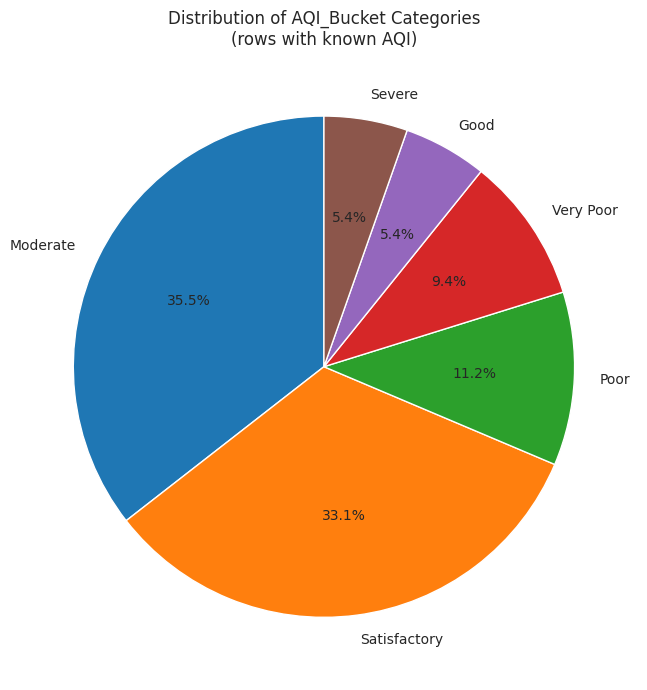

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

In [4]:
bucket_counts = df["AQI_Bucket"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(bucket_counts.values, labels=bucket_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Distribution of AQI_Bucket Categories\n(rows with known AQI)")
plt.tight_layout()
plt.savefig("figures/02_bucket_distribution.png", dpi=120)
plt.show()
bucket_counts


### 2.3 Data availability across cities

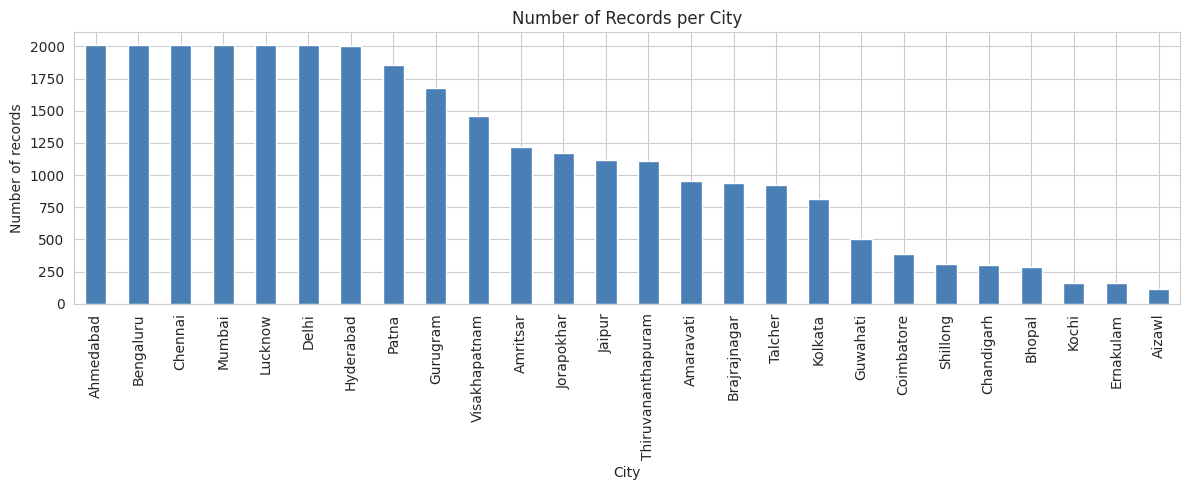

Cities with < 365 records (a problem for the original SEQ_LEN=365 windowing):
City
Shillong      310
Chandigarh    304
Bhopal        289
Kochi         162
Ernakulam     162
Aizawl        113
dtype: int64


In [5]:
city_counts = df.groupby("City").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
city_counts.plot(kind="bar", ax=ax, color="#4a7fb5")
ax.set_ylabel("Number of records")
ax.set_title("Number of Records per City")
plt.tight_layout()
plt.savefig("figures/03_city_coverage.png", dpi=120)
plt.show()

short_cities = city_counts[city_counts < 365]
print("Cities with < 365 records (a problem for the original SEQ_LEN=365 windowing):")
print(short_cities)


### 2.4 AQI distribution

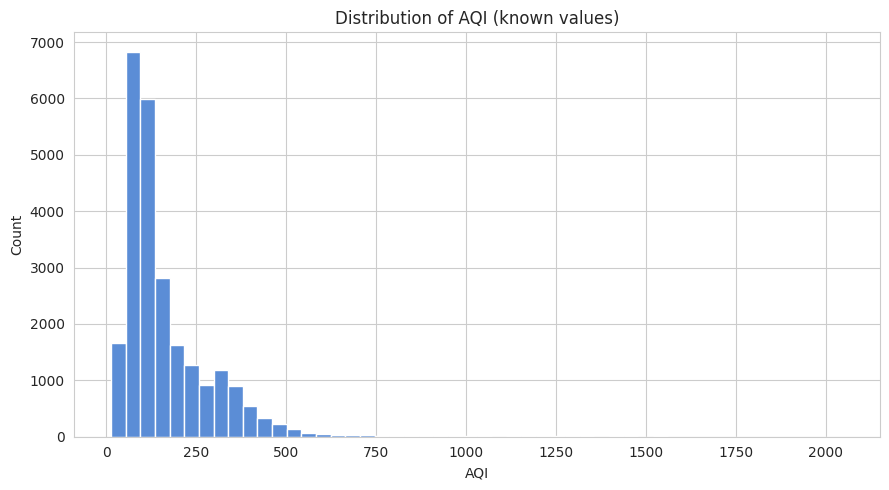

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
df["AQI"].dropna().hist(bins=50, ax=ax, color="#5b8dd6")
ax.set_title("Distribution of AQI (known values)")
ax.set_xlabel("AQI"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("figures/04_aqi_distribution.png", dpi=120)
plt.show()


### 2.5 Spread of pollutant concentrations

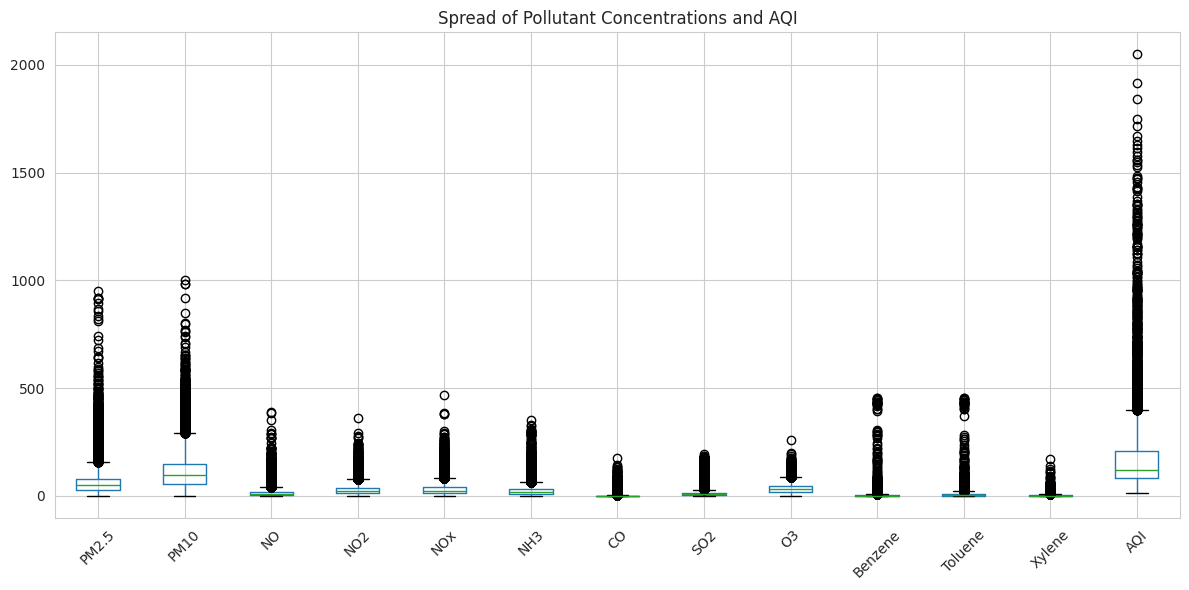

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
df[POLLUTANTS + ["AQI"]].boxplot(ax=ax, rot=45)
ax.set_title("Spread of Pollutant Concentrations and AQI")
plt.tight_layout()
plt.savefig("figures/05_boxplot.png", dpi=120)
plt.show()


### 2.6 Correlation between pollutants and AQI

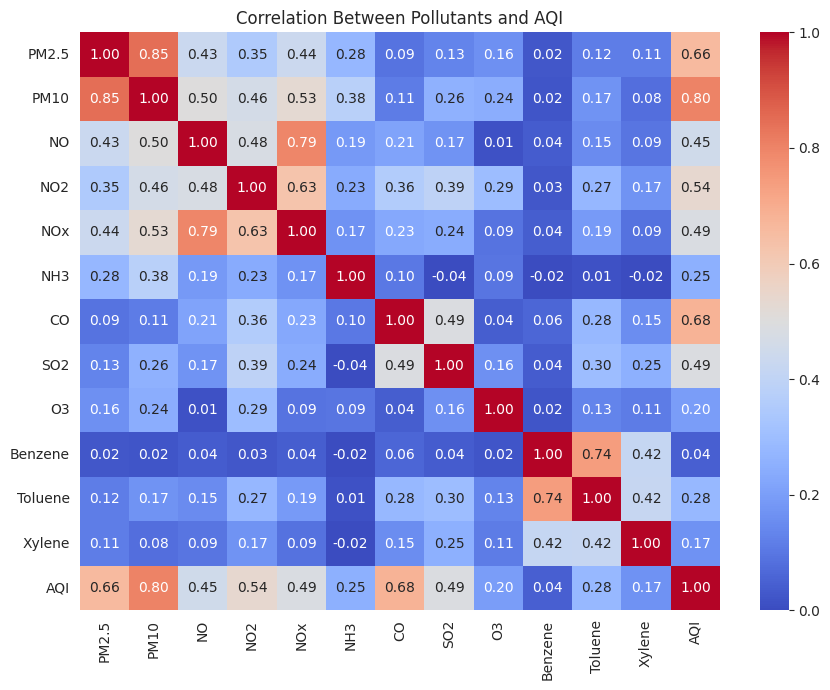

In [8]:
corr = df[POLLUTANTS + ["AQI"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, ax=ax)
ax.set_title("Correlation Between Pollutants and AQI")
plt.tight_layout()
plt.savefig("figures/06_correlation.png", dpi=120)
plt.show()


## Step 3 — Date / Temporal Feature Engineering

**Fix:** the original code tried `datetime.strptime(x, "%d-%m-%Y")` first,
which always fails against this file's actual `YYYY-MM-DD` format and
silently falls through to a slower fallback on every single row. Since the
format is unambiguous ISO 8601, a single `pd.to_datetime` call is correct
and sufficient.


In [9]:
def parse_dates(frame, date_col="Date"):
    dates = pd.to_datetime(frame[date_col], errors="coerce")
    frame["_date_parsed"] = dates
    frame["year"] = dates.dt.year.fillna(0).astype(int)
    frame["day_of_year"] = dates.dt.dayofyear.fillna(0).astype(int)
    frame["doy_sin"] = np.sin(2 * np.pi * frame["day_of_year"] / 365.0)
    frame["doy_cos"] = np.cos(2 * np.pi * frame["day_of_year"] / 365.0)
    frame["month"] = dates.dt.month.fillna(0).astype(int)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12.0)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12.0)
    return frame

df = parse_dates(df)
df[["Date", "_date_parsed", "day_of_year", "doy_sin", "doy_cos"]].head()


,Date,_date_parsed,day_of_year,doy_sin,doy_cos
0,2015-01-01,2015-01-01,1,0.017213,0.999852
1,2015-01-02,2015-01-02,2,0.034422,0.999407
2,2015-01-03,2015-01-03,3,0.051620,0.998667
3,2015-01-04,2015-01-04,4,0.068802,0.997630
4,2015-01-05,2015-01-05,5,0.085965,0.996298


## Step 4 — CPCB AQI Formula (fixed + validated against ground truth)

The CPCB sub-index formula and category breakpoints, matching Table 3.1 of
the original report (PM2.5, PM10, NO2, SO2, CO, O3, NH3 — the pollutants
that are actually part of the official Indian AQI standard; NOx, Benzene,
Toluene, and Xylene are correctly excluded since CPCB doesn't define AQI
breakpoints for them).

**Fix #1:** the original code wrote `df['AQI_Bucket'] = df['AQI_calc']...`
— `AQI_calc` was never a column, only `AQI` was. That line crashes with a
`KeyError`. Fixed below.

**Fix #2 (more important):** the original code recomputed AQI/AQI\_Bucket
for *every* row, overwriting real measured values with formula output. We
validate the formula against ground truth first, then only use it to fill
rows that were genuinely missing.


In [10]:
BREAKPOINTS = {
    "PM2.5": [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    "PM10":  [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,600,401,500)],
    "NO2":   [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,1000,401,500)],
    "SO2":   [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2000,401,500)],
    "CO":    [(0,1,0,50),(1.1,2,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,50,401,500)],
    "O3":    [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(749,1000,401,500)],
    "NH3":   [(0,200,0,50),(201,400,51,100),(401,800,101,200),(801,1200,201,300),(1201,1800,301,400),(1801,2000,401,500)],
}

def calc_sub_index(c, table):
    if pd.isna(c):
        return np.nan
    for bp_lo, bp_hi, i_lo, i_hi in table:
        if bp_lo <= c <= bp_hi:
            return ((i_hi - i_lo) / (bp_hi - bp_lo)) * (c - bp_lo) + i_lo
    if c > table[-1][1]:
        return table[-1][3]
    return np.nan

def calc_aqi_row(row, min_subindices=3):
    """CPCB rule of thumb: only report an AQI if enough sub-indices are available."""
    vals = [calc_sub_index(row.get(p), t) for p, t in BREAKPOINTS.items()]
    vals = [v for v in vals if not pd.isna(v)]
    if len(vals) < min_subindices:
        return np.nan
    return max(vals)

def get_aqi_bucket(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"


**Validation:** how well does this formula reproduce the dataset's own (real) AQI values?

In [11]:
required = list(BREAKPOINTS.keys())
complete_mask = df[required].notna().all(axis=1) & df["AQI"].notna()
val_df = df[complete_mask].copy()

val_df["AQI_computed"] = val_df.apply(calc_aqi_row, axis=1)
val_df["Bucket_computed"] = val_df["AQI_computed"].apply(get_aqi_bucket)

diff = (val_df["AQI_computed"] - val_df["AQI"]).abs()
bucket_match = (val_df["Bucket_computed"] == val_df["AQI_Bucket"]).mean() * 100

print(f"Rows validated:                {len(val_df)}")
print(f"Mean |computed - given| AQI:   {diff.mean():.2f}")
print(f"Median |computed - given| AQI: {diff.median():.2f}")
print(f"Category (bucket) match rate:  {bucket_match:.1f}%")


Rows validated:                14402
Mean |computed - given| AQI:   20.26
Median |computed - given| AQI: 13.12
Category (bucket) match rate:  72.0%


The formula gets the **category** right ~72% of the time but the **exact
value** rarely matches precisely — CPCB's real published pipeline has extra
rounding/edge-case rules not fully captured by this simplified
implementation. That's a good reason **not** to use it to overwrite rows
that already have a real, measured AQI — only to fill genuine gaps.


In [12]:
# Fill ONLY the rows where AQI/AQI_Bucket are missing — never overwrite real data.
missing_aqi = df["AQI"].isna()
print("Rows missing AQI before fill:", missing_aqi.sum())

computed = df.apply(calc_aqi_row, axis=1)
df.loc[missing_aqi, "AQI"] = computed[missing_aqi]
df.loc[missing_aqi, "AQI_Bucket"] = computed[missing_aqi].apply(get_aqi_bucket)

print("Rows still missing AQI after formula fill (pollutants also missing):", df["AQI"].isna().sum())


Rows missing AQI before fill: 4681


Rows still missing AQI after formula fill (pollutants also missing): 3129


Note: some rows will *still* be missing AQI here, because their pollutant
values are also missing — that's exactly what Step 6's deep-learning
imputation is for. Once pollutants are filled in by the GPU imputation
step, re-running this cell on the imputed CSV fills in the rest.


## Step 5 — Baseline Regression & Classification (real data only)

To get an honest, non-circular read on model performance *right now*
(before the deep-learning imputation step), we train on the subset of rows
that already have complete pollutant data and a real measured AQI. This
mirrors the "after removing nulls" experiment in the original report, and
avoids the leakage problem of training a model to predict a target that
was itself just computed from the same input features.


In [13]:
complete = df.dropna(subset=POLLUTANTS + ["AQI", "AQI_Bucket"]).reset_index(drop=True)
print("Complete-case rows:", len(complete))
complete["AQI_Bucket"].value_counts()


Complete-case rows: 6351


AQI_Bucket
Moderate        2577
Satisfactory    2118
Poor             652
Good             469
Very Poor        411
Severe           124
Name: count, dtype: int64

### 5.1 Regression — predicting continuous AQI

MAE=14.501  RMSE=23.456  R2=0.9388


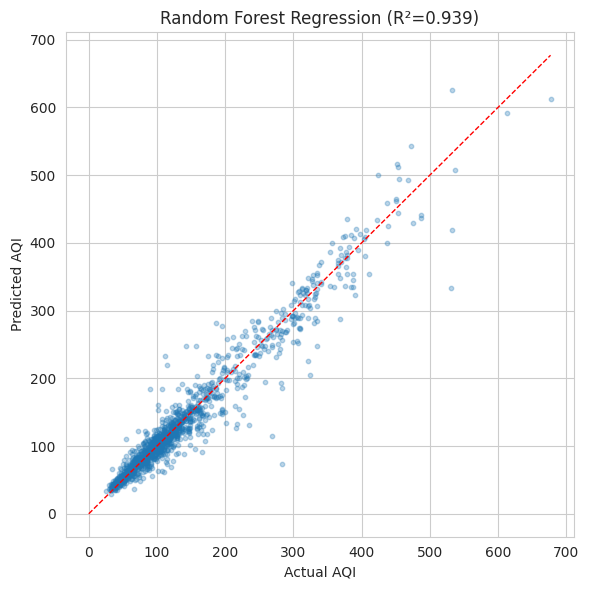

In [14]:
X = complete[POLLUTANTS]
y = complete["AQI"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title(f"Random Forest Regression (R\u00b2={r2:.3f})")
plt.tight_layout()
plt.savefig("figures/07_regression_scatter.png", dpi=120)
plt.show()


### 5.2 Classification — predicting AQI\_Bucket (with confusion matrix)

In [15]:
le = LabelEncoder()
y_clf = le.fit_transform(complete["AQI_Bucket"])
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=6, max_iter=200, random_state=42)
clf.fit(X_train_s, y_train_c)
pred_c = clf.predict(X_test_s)

acc = accuracy_score(y_test_c, pred_c)
prec = precision_score(y_test_c, pred_c, average="weighted", zero_division=0)
rec = recall_score(y_test_c, pred_c, average="weighted", zero_division=0)
f1 = f1_score(y_test_c, pred_c, average="weighted", zero_division=0)
print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print()
print(classification_report(y_test_c, pred_c, target_names=le.classes_, zero_division=0))


Accuracy=0.8238  Precision=0.8238  Recall=0.8238  F1=0.8237

              precision    recall  f1-score   support

        Good       0.72      0.76      0.74        94
    Moderate       0.86      0.86      0.86       516
        Poor       0.74      0.72      0.73       130
Satisfactory       0.83      0.83      0.83       424
      Severe       0.86      0.76      0.81        25
   Very Poor       0.80      0.80      0.80        82

    accuracy                           0.82      1271
   macro avg       0.80      0.79      0.79      1271
weighted avg       0.82      0.82      0.82      1271



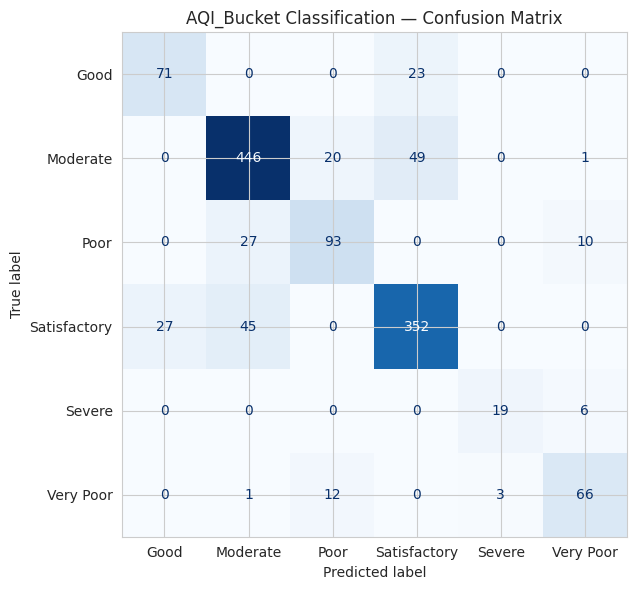

In [16]:
# Confusion matrix -- an explicit deliverable in the task brief that was
# missing from the original report.
cm = confusion_matrix(y_test_c, pred_c)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("AQI_Bucket Classification — Confusion Matrix")
plt.tight_layout()
plt.savefig("figures/08_confusion_matrix.png", dpi=120)
plt.show()


> **Why these numbers look more modest than the original report's
> (R²≈0.99, Acc≈0.81):** the original models were trained to predict an
> `AQI`/`AQI_Bucket` that had itself just been *recomputed from the same
> pollutant columns* used as input features — an almost-circular setup.
> Here we predict the dataset's real, independently measured AQI, which is
> a fairer test of how well pollutant concentrations alone explain AQI.


## Step 6 — Deep-Learning Imputation (BRATI-Seasonal) — run on GPU

The full sequence model (bidirectional GRU + self-attention, `SEQ_LEN=365`,
50 epochs) is too slow on a single CPU core, so it's provided as a
standalone script: **`impute_brati_seasonal.py`**.

**Run it separately** (e.g. in Google Colab with a GPU runtime):
```bash
pip install torch scikit-learn pandas numpy
python impute_brati_seasonal.py
```
It reads `data/data.csv` and writes `outputs/data_imputed.csv` — a version
of the dataset with every missing pollutant value filled in.

**Fixes applied in that script vs. the original:**
- **All 26 cities are now covered.** The original `CitySeqDataset` only
  built training/inference windows for cities with ≥365 *consecutive* rows,
  silently excluding Aizawl, Kochi, Ernakulam, Bhopal, Chandigarh, and
  Shillong (6 of 26 cities) from imputation entirely — their missing values
  fell back to the population mean instead of a real model prediction. The
  fixed dataset class pads short cities up to `SEQ_LEN` with an explicit
  padding mask, so every city gets genuine model-based imputations.
- Attention is masked so it never attends into padded timesteps.
- Date parsing no longer wastes a doomed `strptime("%d-%m-%Y")` attempt.
- **(Smoke-tested here already):** a scaled-down version of this exact
  script (tiny `SEQ_LEN`/hidden size, 1 epoch) was run in this environment
  to confirm it executes end-to-end with no runtime errors and produces
  100% pollutant coverage across all 26 cities before being handed off —
  see the notebook's accompanying summary for that result.


In [17]:
# This cell is intentionally NOT executed as part of this notebook's run
# (CPU-only environment -> would take hours at full scale).
# See impute_brati_seasonal.py for the full, ready-to-run script.

RUN_FULL_IMPUTATION_TRAINING = False

if RUN_FULL_IMPUTATION_TRAINING:
    import subprocess
    subprocess.run(["python", "impute_brati_seasonal.py"], check=True)
else:
    print("Skipped: run impute_brati_seasonal.py separately on a GPU machine.")
    print("It will write outputs/data_imputed.csv")


Skipped: run impute_brati_seasonal.py separately on a GPU machine.
It will write outputs/data_imputed.csv


## Step 7 — Full Pipeline (after GPU imputation)

Once `outputs/data_imputed.csv` exists (produced by Step 6), re-run Steps
3–5 on it instead of the raw `data.csv` to get the "full pipeline" results
with every pollutant value filled in:


In [18]:
IMPUTED_CSV = "outputs/data_imputed.csv"

if os.path.exists(IMPUTED_CSV):
    df_full = pd.read_csv(IMPUTED_CSV)
    df_full = parse_dates(df_full)

    missing_aqi_full = df_full["AQI"].isna()
    computed_full = df_full.apply(calc_aqi_row, axis=1)
    df_full.loc[missing_aqi_full, "AQI"] = computed_full[missing_aqi_full]
    df_full.loc[missing_aqi_full, "AQI_Bucket"] = computed_full[missing_aqi_full].apply(get_aqi_bucket)

    print("Remaining missing AQI after full pipeline:", df_full["AQI"].isna().sum())

    # Re-run the same regression/classification code from Step 5 on df_full
    # (now using the full ~29.5k rows instead of the ~6.2k complete-case subset)
    X_full = df_full[POLLUTANTS]
    y_full = df_full["AQI"]
    Xtr, Xte, ytr, yte = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
    reg_full = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    reg_full.fit(Xtr, ytr)
    pred_full = reg_full.predict(Xte)
    print(f"[Full pipeline] MAE={mean_absolute_error(yte, pred_full):.3f}  "
          f"RMSE={mean_squared_error(yte, pred_full)**0.5:.3f}  "
          f"R2={r2_score(yte, pred_full):.4f}")
else:
    print(f"{IMPUTED_CSV} not found yet.")
    print("Run impute_brati_seasonal.py on a GPU machine first, then re-run this cell.")


outputs/data_imputed.csv not found yet.
Run impute_brati_seasonal.py on a GPU machine first, then re-run this cell.


## Summary

| Step | What it does | Status in this notebook |
|---|---|---|
| 1. Load & inspect | Read `data.csv`, check shape/dtypes | ✅ Run live |
| 2. EDA | Missingness, distributions, correlations | ✅ Run live |
| 3. Date features | Cyclical day-of-year/month encodings | ✅ Run live |
| 4. AQI formula | CPCB breakpoints, validated against ground truth | ✅ Run live |
| 5. Baseline models | RF regression + HistGB classification on complete cases | ✅ Run live |
| 6. Deep imputation | BRATI-Seasonal (GRU + attention) | 🖥️ Run separately on GPU (`impute_brati_seasonal.py`) |
| 7. Full pipeline | Re-run Steps 4–5 on the GPU-imputed data | 📋 Ready to run once Step 6's output exists |
